<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/AgrupamientoTextos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Agrupamiento de textos**

* Asignatura: Procesamiento del Lenguaje Natural
* Profesor: Dr. Rogelio Florencia Juárez
* Alumno: **Álvaro Hernández Jarquín**
* Matrícula: 263150
* 27 de abril de 2026




En esta actividad se deberán aplicar técnicas de clustering sobre un conjunto de textos en inglés. Entrenar tus propios embeddings para crear las representaciones vectoriales, las cuales se deberán utilizar para entrenar los algoritmos K-Means y DBSCAN. Compara sus resultados utilizando las métricas internas de evaluación vistas en clase y genera visualizaciones para interpretar los agrupamientos generados por ambos algoritmos. En base a las métricas define el mejor modelo y, para K-Means, el mejor valor de K.

# **Instrucciones**

## 1. Carga y preparación de datos

### a) Utiliza el dataset: 20 Newsgroups (sklearn.datasets.fetch_20newsgroups)

Esta es la manera de utilizarlo:

```python
from sklearn.datasets import fetch_20newsgroups
dataset = fetch_20newsgroups(subset='all', remove=('headers','footers','quotes'))
docs_raw = dataset.data
```

Los textos están en dataset.data, los cuales asigné a la variable docs_raw. Integren lo anterior en su código. La primera vez que ejecuten su código podría tardar varios minutos.

### b) Realiza el preprocesamiento del texto, incluyendo como mínimo:

* Conversión a minúsculas
* Eliminación de signos de puntuación
* Eliminación de stopwords en inglés
* Tokenización

### c) Entrena tus propios embeddings. Los vectores deben ser de tamaño 100

## 2. Clustering con K-Means

### a) Entrena K-Means utilizando los embeddings obtenidos

### b) Determina el mejor valor de K utilizando:

* Método del Codo (Elbow Method)
* Coeficiente de Silhouette

### c) Muestra las gráficas correspondientes y explica brevemente cómo elegiste el valor óptimo

### d) Entrena nuevamente K-Means usando ese K óptimo

### e) Calcula y reporta las métricas:

* Silhouette
* Davies–Bouldin Index (DB)
* Calinski–Harabasz (CH)

## 3. Clustering con DBSCAN

### a) Entrena un modelo DBSCAN utilizando el mismo conjunto de embeddings

### b) Ajusta los hiperparámetros eps y min_samples (explora varios valores)

### c) Calcula las mismas métricas internas:

* Silhouette
* Davies–Bouldin
* Calinski–Harabasz

## 4. Comparación de resultados

### a) Construye una tabla comparativa donde muestres los valores de las métricas obtenidas con ambos modelos

### b) Escribe una conclusión técnica, indicando qué algoritmo funcionó mejor basándote en las métricas, no en opinión personal

## 5. Visualizaciones

### a) PCA o t-SNE en 2D mostrando los clusters de K-Means

### b) PCA o t-SNE en 2D mostrando los clusters de DBSCAN

### c) Nube de palabras por cluster (para ambos modelos)

# **Entregables**

* Código como archivo .ipynb o .py (si estás trabajando en Google Colab, descarga el código para que lo envíes)

* Documento PDF donde reportes:
  * Los hallazgos de la experimentación
  * Las pruebas realizadas
  * Mejores valores para ambos algoritmos
  * Tabla comparativa de resultados
  * Visualizaciones
  * Observaciones y conclusiones

In [1]:
# Instalamos, importamos y descargamos recursos necesarios
!pip install gensim -q

import re
import time
from collections import Counter
import numpy as np
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.datasets import fetch_20newsgroups
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 24.2 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## **1. Carga y preparación de datos**

In [2]:
# 1.a Carga del dataset 20 Newsgroups
print("Cargando dataset...")
dataset = fetch_20newsgroups(
    subset='all',
    remove=('headers','footers','quotes'))
docs_raw = dataset.data

print(f"Total de documentos cargados: {len(docs_raw)}")
print(f"\nEjemplo del primer documento (primeros 200 caracteres):{docs_raw[0][:200]}...")

Cargando dataset...
Total de documentos cargados: 18846

Ejemplo del primer documento (primeros 200 caracteres):

I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However,...


In [3]:
# 1.b Preprocesamiento
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Convierte el texto a minúsculas, elimina puntuación/números,
    tokeniza y elimina stopwords y caracteres sueltos.
    """
    # Minúsculas
    text = text.lower()
    # Eliminar signos de puntuación y números
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenización
    tokens = word_tokenize(text)
    # Eliminar stopwords y palabras de 1 letra
    tokens = [word for word in tokens if word not in stop_words and len(word) > 1]
    return tokens

print("Preprocesando 18,846 documentos...")
tokenized_docs = [preprocess_text(doc) for doc in docs_raw]

total_tokens = sum(len(doc) for doc in tokenized_docs)

print(f"Preprocesamiento completado.")
print(f"Documentos: {len(tokenized_docs)}")
print(f"Total de tokens después de limpieza: {total_tokens}")
print(f"Ejemplo (primeros 20 tokens del doc 0):\n{tokenized_docs[0][:20]}")

Preprocesando 18,846 documentos...
Preprocesamiento completado.
Documentos: 18846
Total de tokens después de limpieza: 1771385
Ejemplo (primeros 20 tokens del doc 0):
['sure', 'bashers', 'pens', 'fans', 'pretty', 'confused', 'lack', 'kind', 'posts', 'recent', 'pens', 'massacre', 'devils', 'actually', 'bit', 'puzzled', 'bit', 'relieved', 'however', 'going']


In [4]:
# 1.c Entrenar embeddings
print("Entrenando Word2Vec con vectores de tamaño 100...")
start_time = time.time()

# Parámetros comunes para Word2Vec
modelo_w2v = Word2Vec(sentences=tokenized_docs,
                      vector_size=100,
                      window=5,
                      min_count=5,
                      workers=4,
                      sg=0)

end_time = time.time()

print(f"Entrenamiento completado en {end_time - start_time:.2f} segundos.")
print(f"Tamaño del vocabulario: {len(modelo_w2v.wv)} palabras")
print("-" * 50)
print("Ejemplo de vector para la palabra 'computer':")
print(modelo_w2v.wv['computer'][:10])  # primeros 10 valores

Entrenando Word2Vec con vectores de tamaño 100...
Entrenamiento completado en 17.46 segundos.
Tamaño del vocabulario: 25210 palabras
--------------------------------------------------
Ejemplo de vector para la palabra 'computer':
[-0.64118665  1.2261721   0.76995593 -0.83643097 -0.00840058 -0.39584813
  0.21051341  0.36510143  0.562943    0.5212928 ]


## **2. Clustering con K-Means**




In [8]:
# Vectorización de documentos
def document_vector(tokens, model):
    """
    Calcula el vector de un documento promediando los embeddings
    de las palabras que lo componen.
    """
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    else:
        return np.mean(vectors, axis=0)

print("Generando vectores para 18,846 documentos...")
start_vec = time.time()

# Creación de la variable doc_vectors que utilizarán K-Means y DBSCAN
doc_vectors = np.array([document_vector(doc, modelo_w2v) for doc in tokenized_docs])

print(f"Vectorización completada en {time.time() - start_vec:.2f} segundos.")
print(f"Shape de la matriz de documentos: {doc_vectors.shape}")
print("Verificando primer documento (vector, primeros 5 valores):")
print(doc_vectors[0][:5])

Generando vectores para 18,846 documentos...
Vectorización completada en 3.99 segundos.
Shape de la matriz de documentos: (18846, 100)
Verificando primer documento (vector, primeros 5 valores):
[-0.1122337   0.17209139  0.43532699  0.27236807 -0.22144242]


Iniciando exploración de K-Means (K=2 hasta K=20)...
Exploración completada en 215.16 segundos.
--------------------------------------------------
Mejores 5 valores de K según Silhouette:
 k  silhouette  davies_bouldin  calinski_harabasz
 2    0.229184        1.688957        5147.952191
 3    0.160710        1.982700        3777.156802
 6    0.157634        1.809207        2542.440827
 9    0.145329        1.628123        2126.008266
10    0.143537        1.689100        2029.008825
--------------------------------------------------
Generando gráficas para K-Means...


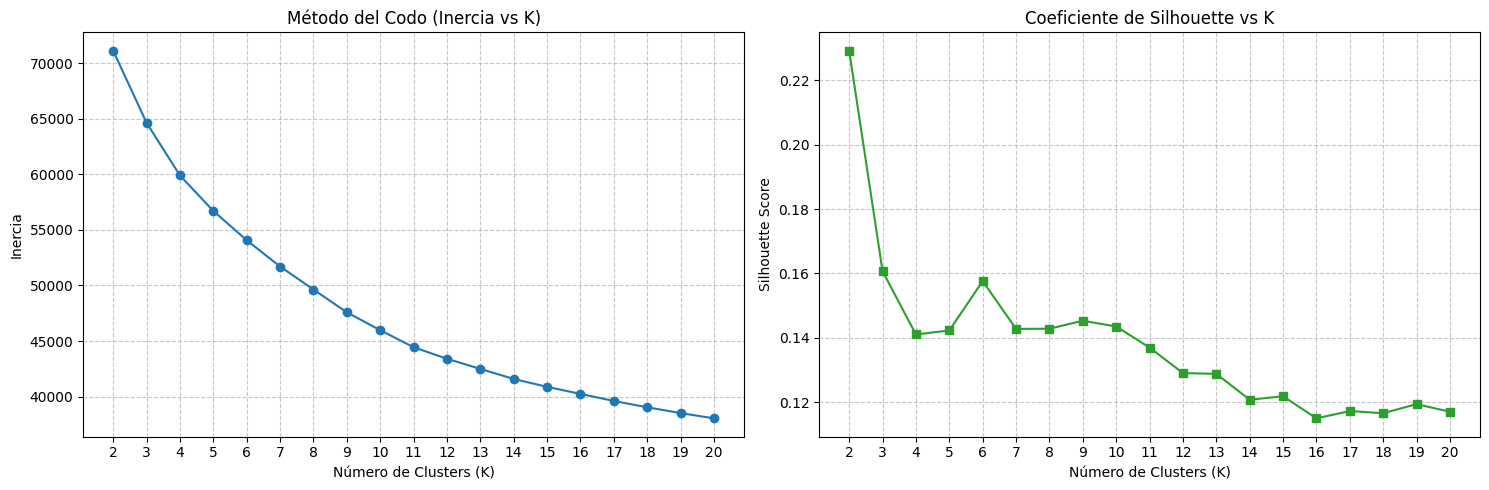

In [10]:
# 2. Clustering con K-Means
print("Iniciando exploración de K-Means (K=2 hasta K=20)...")
start_kmeans = time.time()

k_range = range(2, 21)
kmeans_metrics = []
inercias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_km = km.fit_predict(doc_vectors)

    # Guardar inercia para el Método del Codo
    inercias.append(km.inertia_)

    # Calcular métricas internas
    sil = silhouette_score(doc_vectors, labels_km)
    db = davies_bouldin_score(doc_vectors, labels_km)
    ch = calinski_harabasz_score(doc_vectors, labels_km)

    kmeans_metrics.append({
        'k': k, 'silhouette': sil, 'davies_bouldin': db, 'calinski_harabasz': ch
    })

df_kmeans = pd.DataFrame(kmeans_metrics)

print(f"Exploración completada en {time.time() - start_kmeans:.2f} segundos.")
print("-" * 50)
print("Mejores 5 valores de K según Silhouette:")
print(df_kmeans.sort_values('silhouette', ascending=False).head(5).to_string(index=False))


# 2.c Generación de Gráficas (Método del Codo y Silhouette)
print("-" * 50)
print("Generando gráficas para K-Means...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfica 1: Método del Codo (Inercia)
ax1.plot(k_range, inercias, marker='o', linestyle='-', color='#1f77b4')
ax1.set_title('Método del Codo (Inercia vs K)')
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('Inercia')
ax1.set_xticks(k_range)
ax1.grid(True, linestyle='--', alpha=0.7)

# Gráfica 2: Coeficiente de Silhouette
ax2.plot(df_kmeans['k'], df_kmeans['silhouette'], marker='s', linestyle='-', color='#2ca02c')
ax2.set_title('Coeficiente de Silhouette vs K')
ax2.set_xlabel('Número de Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(k_range)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [9]:
# 2.d Entrenamiento final de K-Means con el K óptimo
# Se selecciona K=6 basado en el balance entre el Coeficiente de Silhouette
best_k = 6

print(f"Entrenando K-Means final con K={best_k}...")
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_km_final = kmeans_final.fit_predict(doc_vectors)

# 2.e Reporte de métricas internas
sil_km = silhouette_score(doc_vectors, labels_km_final)
db_km = davies_bouldin_score(doc_vectors, labels_km_final)
ch_km = calinski_harabasz_score(doc_vectors, labels_km_final)

print("\n=== Métricas finales K-Means ===")
print(f"Número de clusters (K): {best_k}")
print(f"Silhouette Score:      {sil_km:.4f}")
print(f"Davies-Bouldin Index:  {db_km:.4f}")
print(f"Calinski-Harabasz:     {ch_km:.1f}")

Entrenando K-Means final con K=6...

=== Métricas finales K-Means ===
Número de clusters (K): 6
Silhouette Score:      0.1576
Davies-Bouldin Index:  1.8092
Calinski-Harabasz:     2542.4



## **3. Clustering con DBSCAN**




In [11]:
# 3.a	Entrena un modelo DBSCAN utilizando el mismo conjunto de embeddings.
def evaluate_dbscan(doc_vectors, eps, min_samples):
    """Entrena DBSCAN y devuelve métricas internas excluyendo el ruido."""
    db = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean', n_jobs=-1)
    labels = db.fit_predict(doc_vectors)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    # Filtrar ruido para calcular métricas de forma justa
    mask = labels != -1
    if np.sum(mask) >= 2 and n_clusters >= 2:
        sil = silhouette_score(doc_vectors[mask], labels[mask])
        db_score = davies_bouldin_score(doc_vectors[mask], labels[mask])
        ch = calinski_harabasz_score(doc_vectors[mask], labels[mask])
    else:
        sil = db_score = ch = np.nan

    return {
        'eps': eps, 'min_samples': min_samples, 'n_clusters': n_clusters,
        'n_noise': n_noise, 'silhouette': sil, 'davies_bouldin': db_score, 'calinski_harabasz': ch
    }

In [12]:
# 3.b	Ajusta los hiperparámetros eps y min_samples (explora varios valores)

print("--- Exploración de parámetros DBSCAN ---")
eps_values = [0.5, 1.0, 1.5, 2.0, 2.5]
min_samples_values = [5, 10, 20, 50]

for eps in eps_values:
    for min_samples in min_samples_values:
        res = evaluate_dbscan(doc_vectors, eps, min_samples)
        if not np.isnan(res['silhouette']):
            print(f"eps={eps:.1f}, min_samples={min_samples:2d} -> Clusters: {res['n_clusters']}, Ruido: {res['n_noise']}, Silhouette: {res['silhouette']:.3f}")

--- Exploración de parámetros DBSCAN ---
eps=0.5, min_samples= 5 -> Clusters: 48, Ruido: 17731, Silhouette: 0.632
eps=0.5, min_samples=10 -> Clusters: 7, Ruido: 18118, Silhouette: 0.849
eps=0.5, min_samples=20 -> Clusters: 2, Ruido: 18250, Silhouette: 0.985
eps=1.0, min_samples= 5 -> Clusters: 7, Ruido: 5767, Silhouette: 0.020
eps=1.0, min_samples=10 -> Clusters: 4, Ruido: 6028, Silhouette: 0.205
eps=1.0, min_samples=20 -> Clusters: 2, Ruido: 6467, Silhouette: 0.431
eps=1.0, min_samples=50 -> Clusters: 2, Ruido: 7224, Silhouette: 0.319
eps=1.5, min_samples= 5 -> Clusters: 3, Ruido: 1219, Silhouette: 0.365
eps=1.5, min_samples=10 -> Clusters: 2, Ruido: 1286, Silhouette: 0.820
eps=2.0, min_samples= 5 -> Clusters: 3, Ruido: 343, Silhouette: 0.348
eps=2.0, min_samples=10 -> Clusters: 2, Ruido: 359, Silhouette: 0.813
eps=2.5, min_samples= 5 -> Clusters: 2, Ruido: 111, Silhouette: 0.810
eps=2.5, min_samples=10 -> Clusters: 2, Ruido: 117, Silhouette: 0.810


In [13]:
# 3.c Entrenamiento final y cálculo de métricas

# Seleccionamos eps=2.5 y min_samples=5,
best_eps = 2.5
best_min_samples = 5

print(f"Entrenando modelo DBSCAN definitivo con eps={best_eps} y min_samples={best_min_samples}...")
dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples, metric='euclidean', n_jobs=-1)
labels_db_final = dbscan_final.fit_predict(doc_vectors)

# Filtrar el ruido (-1) para el cálculo de las métricas internas
mask = labels_db_final != -1

if np.sum(mask) >= 2 and len(set(labels_db_final[mask])) >= 2:
    sil_db = silhouette_score(doc_vectors[mask], labels_db_final[mask])
    db_score_db = davies_bouldin_score(doc_vectors[mask], labels_db_final[mask])
    ch_db = calinski_harabasz_score(doc_vectors[mask], labels_db_final[mask])
else:
    sil_db = db_score_db = ch_db = np.nan

n_clusters_db = len(set(labels_db_final)) - (1 if -1 in labels_db_final else 0)
n_noise_db = list(labels_db_final).count(-1)

print("\n=== Métricas de Evaluación Final: DBSCAN ===")
print(f"Clusters encontrados:  {n_clusters_db}")
print(f"Puntos de ruido:       {n_noise_db}")
print(f"Silhouette Score:      {sil_db:.4f}")
print(f"Davies-Bouldin Index:  {db_score_db:.4f}")
print(f"Calinski-Harabasz:     {ch_db:.1f}")

Entrenando modelo DBSCAN definitivo con eps=2.5 y min_samples=5...

=== Métricas de Evaluación Final: DBSCAN ===
Clusters encontrados:  2
Puntos de ruido:       111
Silhouette Score:      0.8098
Davies-Bouldin Index:  0.1633
Calinski-Harabasz:     485.2


## **4. Comparación de resultados**

In [14]:
# 4.a Tabla comparativa de resultados
print("\n=== 4.a Tabla comparativa de resultados ===")
tabla_comparativa = pd.DataFrame({
    'Métrica': ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz'],
    'K-Means (K=6)': [sil_km, db_km, ch_km],
    'DBSCAN (eps=2.5, min=5)': [sil_db, db_score_db, ch_db]
})
print(tabla_comparativa.to_string(index=False))
print("\n" + "="*50 + "\n")



=== 4.a Tabla comparativa de resultados ===
          Métrica  K-Means (K=6)  DBSCAN (eps=2.5, min=5)
       Silhouette       0.157634                 0.809778
   Davies-Bouldin       1.809207                 0.163251
Calinski-Harabasz    2542.440827               485.155530




## **5. Visualizaciones**

Reduciendo dimensionalidad a 2D con PCA para las gráficas...


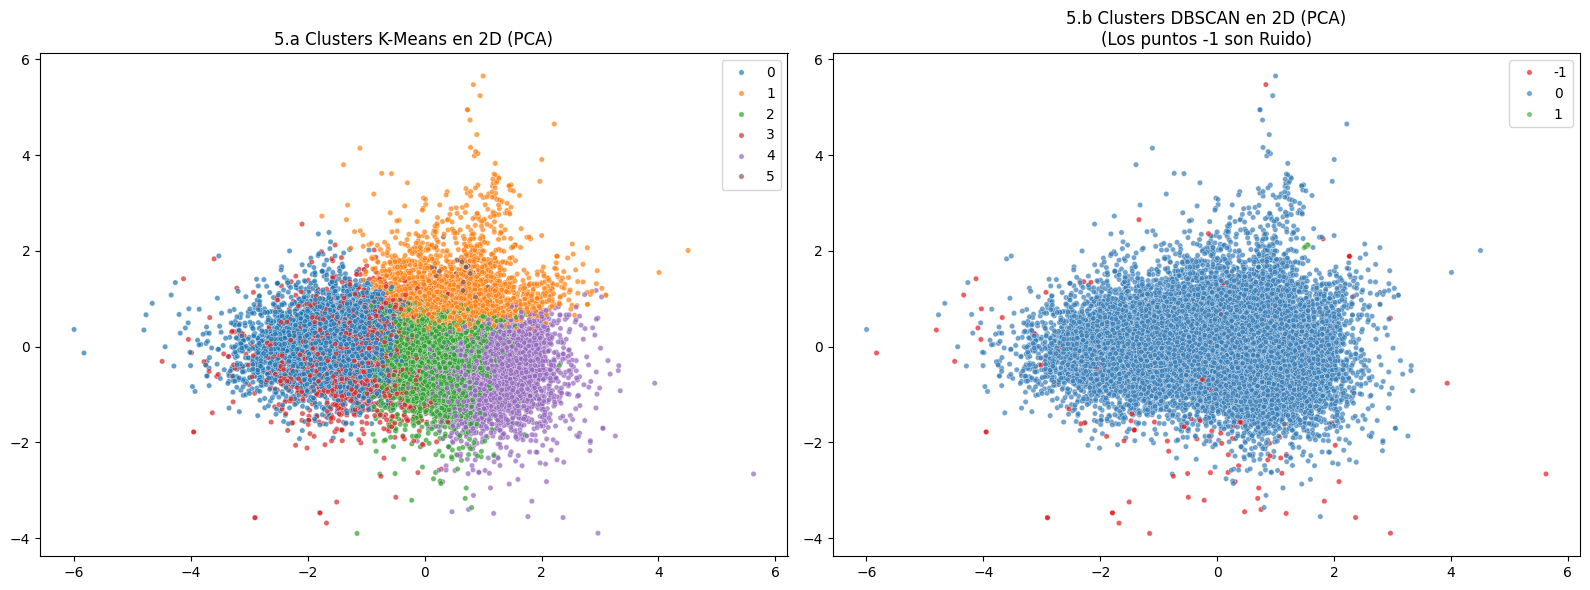

In [15]:
# 5.a y 5.b Visualizaciones PCA 2D
print("Reduciendo dimensionalidad a 2D con PCA para las gráficas...")
pca = PCA(n_components=2, random_state=42)
doc_vectors_2d = pca.fit_transform(doc_vectors)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica K-Means
sns.scatterplot(x=doc_vectors_2d[:, 0], y=doc_vectors_2d[:, 1],
                hue=labels_km_final, palette='tab10', ax=ax1, s=15, alpha=0.7)
ax1.set_title('5.a Clusters K-Means en 2D (PCA)')

# Gráfica DBSCAN (-1 representa el ruido)
sns.scatterplot(x=doc_vectors_2d[:, 0], y=doc_vectors_2d[:, 1],
                hue=labels_db_final, palette='Set1', ax=ax2, s=15, alpha=0.7)
ax2.set_title('5.b Clusters DBSCAN en 2D (PCA)\n(Los puntos -1 son Ruido)')

plt.tight_layout()
plt.show()



Generando nubes de palabras para K-Means...


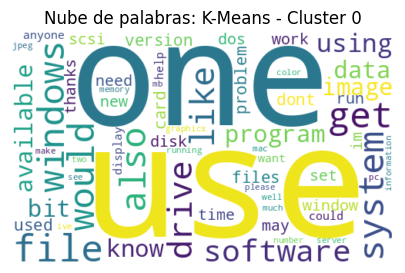

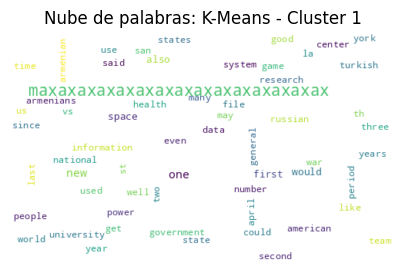

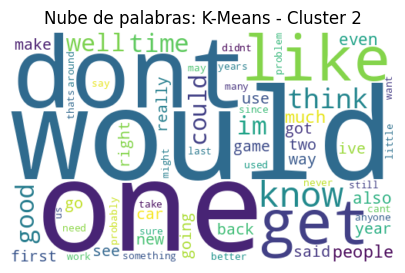

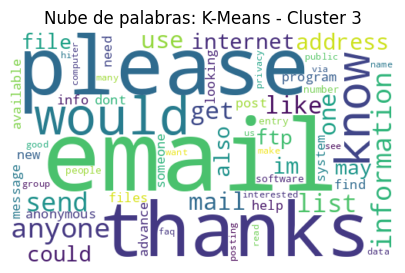

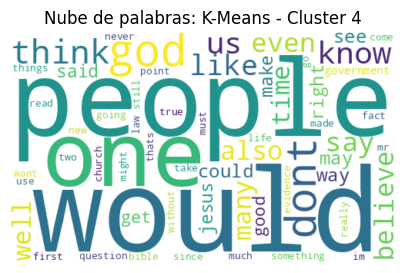

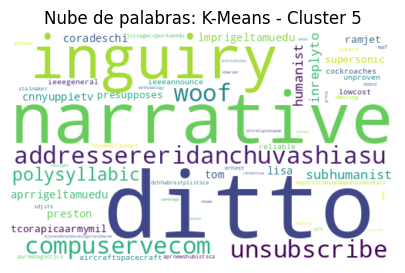




Generando nubes de palabras para DBSCAN...


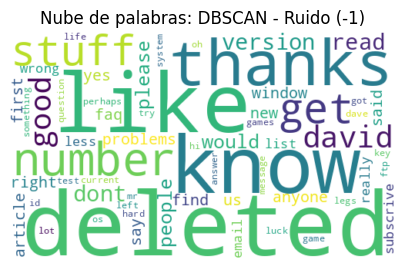

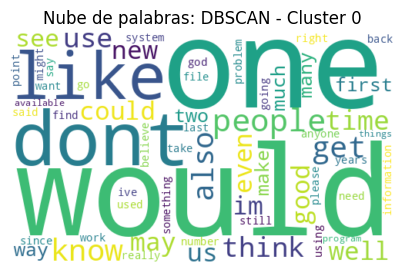

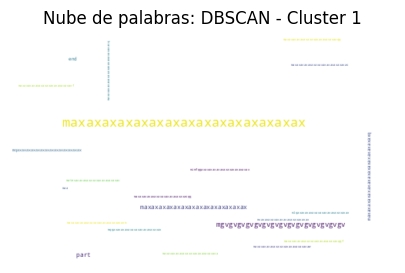

In [16]:
# 5.c Nubes de palabras por Cluster
def generar_nubes_palabras(labels, model_name, max_clusters_to_show=6):
    unique_labels = sorted(list(set(labels)))
    """
    Agrupa los tokens de los documentos pertenecientes a cada clúster
    y genera una nube de palabras basada en su frecuencia.
    """
    for cluster_id in unique_labels:
        # Limitamos la cantidad de nubes a mostrar para no saturar el cuaderno
        if cluster_id >= max_clusters_to_show:
            break

        # Juntar todos los tokens de los documentos de este cluster
        palabras_cluster = []
        for i, doc_tokens in enumerate(tokenized_docs):
            if labels[i] == cluster_id:
                palabras_cluster.extend(doc_tokens)

        # Contar las frecuencias
        frecuencias = Counter(palabras_cluster)

        if len(frecuencias) > 0:
            wc = WordCloud(
                width=500,
                height=300,
                background_color='white',
                max_words=60,
                colormap='viridis'
                ).generate_from_frequencies(frecuencias)

            plt.figure(figsize=(6, 3))
            plt.imshow(wc, interpolation='bilinear')

            titulo = 'Ruido (-1)' if cluster_id == -1 else f'Cluster {cluster_id}'
            plt.title(f'Nube de palabras: {model_name} - {titulo}')
            plt.axis('off')
            plt.show()

print("\nGenerando nubes de palabras para K-Means...")
generar_nubes_palabras(labels_km_final, "K-Means", max_clusters_to_show=6)

print("\n" + "="*50 + "\n")

print("\nGenerando nubes de palabras para DBSCAN...")
generar_nubes_palabras(labels_db_final, "DBSCAN", max_clusters_to_show=3)